In [51]:
import torch
from dinosaw.models.vit_wrapper import MODEL_LIST, PretrainedViTWrapper, AlibiVitWrapper
from dinosaw.comaprisons.denoising_vits import DenoisingViTWrapper 
from dinosaw.utils import do_2D_pca, to_numpy, closest_resize, convert_image, load_image

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

half = False

In [52]:
S = 14
dv2_model = PretrainedViTWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)

dv2_model.eval()
if half:
    dv2_model.half()
None

In [53]:
S = 14
nope_model = PretrainedViTWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)
weights = torch.load("../../experiments/20260127_1505/best_model.pth", weights_only=True, map_location="cuda:0")
nope_model.load_state_dict(weights)
nope_model.eval()
print(nope_model.model.pos_embed)
if half:
    nope_model.half()
None

Parameter containing:
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0', requires_grad=True)


In [54]:
dvt_model = DenoisingViTWrapper(
    '../../trained_models/dvt.pth',
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)
dvt_model.eval()
if half:
    dvt_model.half()
None

In [55]:
alibi_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

# weights = torch.load("../../trained_models/alibi_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
# weights = torch.load("../../experiments/20260128_0957/best_model.pth", weights_only=True, map_location="cuda:0")
weights = torch.load("../../experiments/20260128_1530/best_model.pth", weights_only=True, map_location="cuda:0")
alibi_model.load_state_dict(weights)
alibi_model.eval()
if half:
    alibi_model.half()
None

In [56]:
alibi_homog_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

weights = torch.load("../../trained_models/alibi_homog_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
alibi_homog_model.load_state_dict(weights)
alibi_homog_model.eval()
if half:
    alibi_homog_model.half()
None

In [57]:
def get_features(model: PretrainedViTWrapper, pil_img: Image.Image, channel_last: bool=False, channel_blank: bool=False) -> np.ndarray:
    tr = closest_resize(pil_img.height, pil_img.width, 14)
    img_tensor = convert_image(pil_img, tr, device_str="cuda:0", to_half=half)
    with torch.no_grad():
        emb = model.forward_features(img_tensor, make_2D=True)
    emb_np = to_numpy(emb.squeeze(0))
    if channel_blank:
        channels_to_blank = [47, 113, 117, 359]
        emb_np[channels_to_blank, :, :] = 0
    if channel_last:
        emb_np = np.transpose(emb_np, (1, 2, 0))

    return emb_np

In [ ]:
SF = 1
# img_fname = "micro/NMC_2D_crop.png"\
# img_fname = "tests/black_square_518.png"
# img_fname = "tests/diff_shapes_518.png"
img_fname = "tests/default_image.jpg"
# img_fname = "cat.jpg"
# img_fname = "tests/z_c_w.png"
# img_fname = "micro/NMC_2D_less_wide_crop.png"
_img = Image.open(f"../../images/{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.LANCZOS)



FileNotFoundError: [Errno 2] No such file or directory: '../../images/micro/default_image.jpg'

In [ ]:
keys: tuple[str] = ('dv2', 'dvt', 'alibi', 'alibi_h', 'nope')
names: dict[str, str] = {'dv2': 'DINOv2', 'dvt': "DVT", "alibi": "ALiBi(CB)-Dv2", "alibi_h": "ALiBi(H)-Dv2", 'nope': 'NoPE'}
models: dict[str, PretrainedViTWrapper] = {'dv2': dv2_model, 'dvt': dvt_model, 'alibi': alibi_model, 'alibi_h': alibi_homog_model, 'nope': nope_model}

enabled_models = keys

features = {}
features_reduced = {}

In [ ]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, False, False)
    features[model_key] = feats

In [ ]:
for model_key in enabled_models:
    feats = features[model_key]
    features_reduced[model_key] = do_2D_pca(feats, 3, post_norm='minmax')

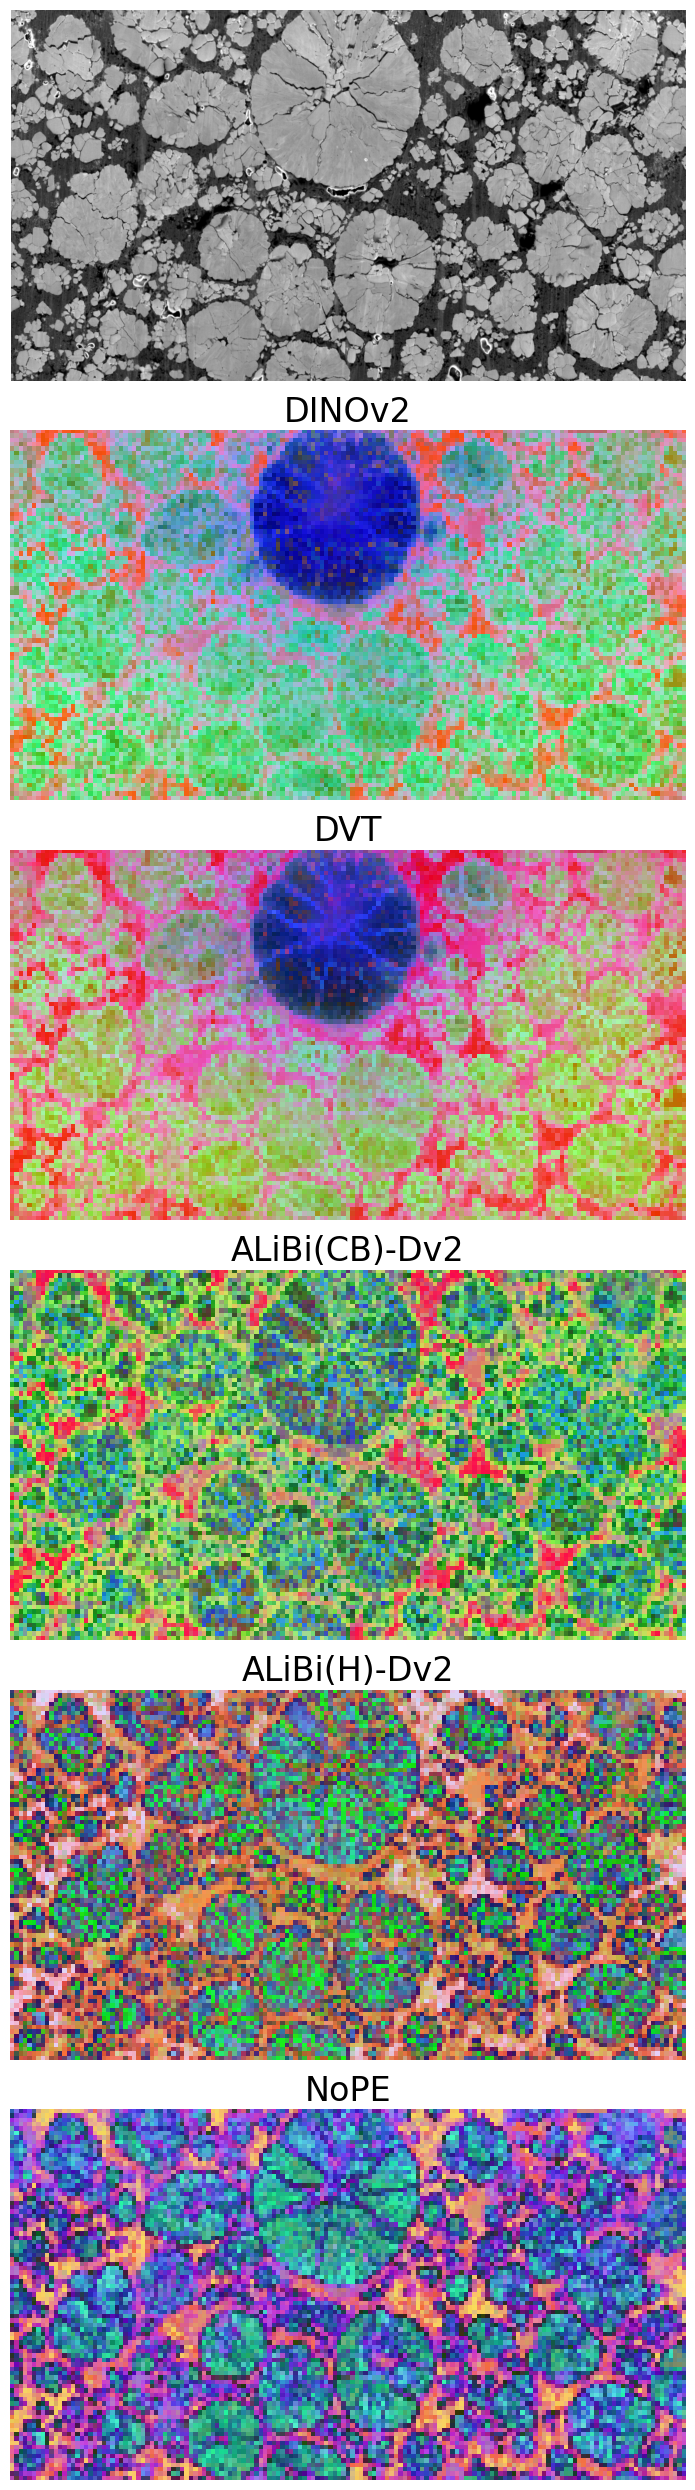

In [ ]:
# %%capture
fig, axs = plt.subplots(nrows=1 + len(keys), ncols=1, figsize=(25, 25))

axs[0].imshow(_img)
axs[0].set_axis_off()
for i, model_key in enumerate(enabled_models):
    feats_red = features_reduced[model_key]
    ax = axs[i + 1]
    ax.set_title(names[model_key], fontsize=24)
    ax.imshow(feats_red)
    ax.set_axis_off()
plt.tight_layout()